<a href="https://colab.research.google.com/github/Erinda27/Data-and-Decision-making-/blob/main/unit_7_consolidate.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Unit 7: Bitcoin and Social Media Marketing
# NLP analysis using Python

!pip install textblob openpyxl wordcloud -q

import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt

from google.colab import files
from IPython.display import display

import nltk
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')

from nltk.corpus import stopwords
from nltk.stem import PorterStemmer, WordNetLemmatizer
from textblob import TextBlob
from collections import Counter
from wordcloud import WordCloud

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...


In [ ]:
uploaded = files.upload()

file_names = list(uploaded.keys())
print("Uploaded files:")
print(file_names)

Saving 8-4 (1).xlsx to 8-4 (1).xlsx
Saving 7-4 (1).xlsx to 7-4 (1).xlsx
Saving 6-4 (1).xlsx to 6-4 (1).xlsx
Saving 5-4 (1).xlsx to 5-4 (1).xlsx
Uploaded files:
['8-4 (1).xlsx', '7-4 (1).xlsx', '6-4 (1).xlsx', '5-4 (1).xlsx']


In [ ]:
all_data = []

for file in file_names:
    temp = pd.read_excel(file)
    temp["source_file"] = file
    all_data.append(temp)

df = pd.concat(all_data, ignore_index=True)

print("Combined dataset shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())

display(df.head())

Combined dataset shape: (378691, 12)

Columns:
['id', 'text', 'created_at', 'author_id', 'in_reply_to_user_id', 'lang', 'author', 'entities', 'referenced_tweets', 'media', 'geo', 'source_file']


,id,text,created_at,author_id,in_reply_to_user_id,lang,author,entities,referenced_tweets,media,geo,source_file
0,1512552392302247936,I’m at @TheBitcoinConf in Miami checking out @...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,8-4 (1).xlsx
1,1512552384400179200,I’m at @TheBitcoinConf in Miami checking out @...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,8-4 (1).xlsx
2,1512552264153583616,I’m at @TheBitcoinConf in Miami checking out @...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,8-4 (1).xlsx
3,1512551962264444928,I’m at @TheBitcoinConf in Miami checking out @...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,8-4 (1).xlsx
4,1512551312298328064,I’m at @TheBitcoinConf in Miami checking out @...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,8-4 (1).xlsx


In [ ]:
print("Data types:")
print(df.dtypes)

print("\nMissing values:")
print(df.isnull().sum())

print("\nDuplicate rows:", df.duplicated().sum())

Data types:
id                       int64
text                    object
created_at             float64
author_id              float64
in_reply_to_user_id    float64
lang                   float64
author                 float64
entities               float64
referenced_tweets      float64
media                  float64
geo                    float64
source_file             object
dtype: object

Missing values:
id                          0
text                        0
created_at             378691
author_id              378691
in_reply_to_user_id    378691
lang                   378691
author                 378691
entities               378691
referenced_tweets      378691
media                  378691
geo                    378691
source_file                 0
dtype: int64

Duplicate rows: 1940


In [ ]:
# Detect possible text/social media post column

text_candidates = []

for col in df.columns:
    if df[col].dtype == "object":
        avg_length = df[col].dropna().astype(str).str.len().mean()
        unique_count = df[col].nunique()
        text_candidates.append((col, avg_length, unique_count))

text_candidates_df = pd.DataFrame(
    text_candidates,
    columns=["column", "average_text_length", "unique_values"]
).sort_values("average_text_length", ascending=False)

display(text_candidates_df)

text_col = text_candidates_df.iloc[0]["column"]

print("Selected text column for NLP:", text_col)

,column,average_text_length,unique_values
0,text,175.772701,356199
1,source_file,12.000000,4


Selected text column for NLP: text


In [ ]:
stop_words = set(stopwords.words("english"))

def clean_text(text):
    text = str(text).lower()
    text = re.sub(r"http\S+|www\S+", "", text)      # remove URLs
    text = re.sub(r"@\w+", "", text)                # remove mentions
    text = re.sub(r"#", "", text)                   # remove hashtag symbol only
    text = re.sub(r"[^a-zA-Z\s]", "", text)         # remove numbers and punctuation
    text = re.sub(r"\s+", " ", text).strip()        # remove extra spaces

    words = text.split()
    words = [word for word in words if word not in stop_words and len(word) > 2]

    return " ".join(words)

df["clean_text"] = df[text_col].apply(clean_text)

display(df[[text_col, "clean_text"]].head(10))

,text,clean_text
0,I’m at @TheBitcoinConf in Miami checking out @...,miami checking trying snag bitcoin thisisarcul...
1,I’m at @TheBitcoinConf in Miami checking out @...,miami checking trying snag bitcoin thisisarcul...
2,I’m at @TheBitcoinConf in Miami checking out @...,miami checking trying snag bitcoin thisisarcul...
3,I’m at @TheBitcoinConf in Miami checking out @...,miami checking trying snag bitcoin thisisarcul...
4,I’m at @TheBitcoinConf in Miami checking out @...,miami checking trying snag bitcoin thisisarcul...
5,I’m at @TheBitcoinConf in Miami checking out @...,miami checking trying snag bitcoin thisisarcul...
6,I’m at @TheBitcoinConf in Miami checking out @...,miami checking trying snag bitcoin thisisarcul...
7,I’m at @TheBitcoinConf in Miami checking out @...,miami checking trying snag bitcoin thisisarcul...
8,I’m at @TheBitcoinConf in Miami checking out @...,miami checking trying snag bitcoin thisisarcul...
9,I’m at @TheBitcoinConf in Miami checking out @...,miami checking trying snag bitcoin thisisarcul...


In [ ]:
# Tokenisation means splitting text into smaller units called tokens

df["tokens"] = df["clean_text"].apply(lambda x: x.split())

display(df[[text_col, "clean_text", "tokens"]].head(10))

print("Example original text:")
print(df[text_col].iloc[0])

print("\nExample cleaned tokens:")
print(df["tokens"].iloc[0])

,text,clean_text,tokens
0,I’m at @TheBitcoinConf in Miami checking out @...,miami checking trying snag bitcoin thisisarcul...,"[miami, checking, trying, snag, bitcoin, thisi..."
1,I’m at @TheBitcoinConf in Miami checking out @...,miami checking trying snag bitcoin thisisarcul...,"[miami, checking, trying, snag, bitcoin, thisi..."
2,I’m at @TheBitcoinConf in Miami checking out @...,miami checking trying snag bitcoin thisisarcul...,"[miami, checking, trying, snag, bitcoin, thisi..."
3,I’m at @TheBitcoinConf in Miami checking out @...,miami checking trying snag bitcoin thisisarcul...,"[miami, checking, trying, snag, bitcoin, thisi..."
4,I’m at @TheBitcoinConf in Miami checking out @...,miami checking trying snag bitcoin thisisarcul...,"[miami, checking, trying, snag, bitcoin, thisi..."
5,I’m at @TheBitcoinConf in Miami checking out @...,miami checking trying snag bitcoin thisisarcul...,"[miami, checking, trying, snag, bitcoin, thisi..."
6,I’m at @TheBitcoinConf in Miami checking out @...,miami checking trying snag bitcoin thisisarcul...,"[miami, checking, trying, snag, bitcoin, thisi..."
7,I’m at @TheBitcoinConf in Miami checking out @...,miami checking trying snag bitcoin thisisarcul...,"[miami, checking, trying, snag, bitcoin, thisi..."
8,I’m at @TheBitcoinConf in Miami checking out @...,miami checking trying snag bitcoin thisisarcul...,"[miami, checking, trying, snag, bitcoin, thisi..."
9,I’m at @TheBitcoinConf in Miami checking out @...,miami checking trying snag bitcoin thisisarcul...,"[miami, checking, trying, snag, bitcoin, thisi..."


Example original text:
I’m at @TheBitcoinConf in Miami checking out @thisisarculus and trying to snag Bitcoin or #thisisarculus swag.

Example cleaned tokens:
['miami', 'checking', 'trying', 'snag', 'bitcoin', 'thisisarculus', 'swag']


In [ ]:
stemmer = PorterStemmer()
lemmatizer = WordNetLemmatizer()

def stem_tokens(tokens):
    return [stemmer.stem(word) for word in tokens]

def lemmatize_tokens(tokens):
    return [lemmatizer.lemmatize(word) for word in tokens]

df["stemmed_tokens"] = df["tokens"].apply(stem_tokens)
df["lemmatized_tokens"] = df["tokens"].apply(lemmatize_tokens)

display(df[["tokens", "stemmed_tokens", "lemmatized_tokens"]].head(10))

,tokens,stemmed_tokens,lemmatized_tokens
0,"[miami, checking, trying, snag, bitcoin, thisi...","[miami, check, tri, snag, bitcoin, thisisarcul...","[miami, checking, trying, snag, bitcoin, thisi..."
1,"[miami, checking, trying, snag, bitcoin, thisi...","[miami, check, tri, snag, bitcoin, thisisarcul...","[miami, checking, trying, snag, bitcoin, thisi..."
2,"[miami, checking, trying, snag, bitcoin, thisi...","[miami, check, tri, snag, bitcoin, thisisarcul...","[miami, checking, trying, snag, bitcoin, thisi..."
3,"[miami, checking, trying, snag, bitcoin, thisi...","[miami, check, tri, snag, bitcoin, thisisarcul...","[miami, checking, trying, snag, bitcoin, thisi..."
4,"[miami, checking, trying, snag, bitcoin, thisi...","[miami, check, tri, snag, bitcoin, thisisarcul...","[miami, checking, trying, snag, bitcoin, thisi..."
5,"[miami, checking, trying, snag, bitcoin, thisi...","[miami, check, tri, snag, bitcoin, thisisarcul...","[miami, checking, trying, snag, bitcoin, thisi..."
6,"[miami, checking, trying, snag, bitcoin, thisi...","[miami, check, tri, snag, bitcoin, thisisarcul...","[miami, checking, trying, snag, bitcoin, thisi..."
7,"[miami, checking, trying, snag, bitcoin, thisi...","[miami, check, tri, snag, bitcoin, thisisarcul...","[miami, checking, trying, snag, bitcoin, thisi..."
8,"[miami, checking, trying, snag, bitcoin, thisi...","[miami, check, tri, snag, bitcoin, thisisarcul...","[miami, checking, trying, snag, bitcoin, thisi..."
9,"[miami, checking, trying, snag, bitcoin, thisi...","[miami, check, tri, snag, bitcoin, thisisarcul...","[miami, checking, trying, snag, bitcoin, thisi..."


,word,frequency
0,bitcoin,400711
1,btc,109844
2,crypto,93730
3,cryptocurrency,52640
4,eth,48299
5,ethereum,45105
6,price,44861
7,nft,39888
8,binance,38125
9,project,32820


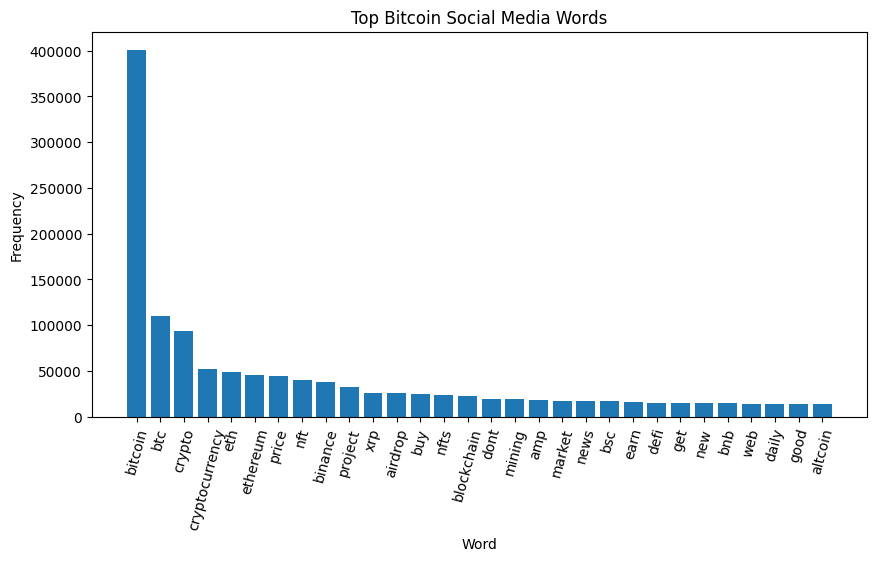

In [ ]:
all_words = []

for tokens in df["lemmatized_tokens"]:
    all_words.extend(tokens)

word_freq = Counter(all_words)

word_freq_df = pd.DataFrame(
    word_freq.most_common(30),
    columns=["word", "frequency"]
)

display(word_freq_df)

plt.figure(figsize=(10, 5))
plt.bar(word_freq_df["word"], word_freq_df["frequency"])
plt.xticks(rotation=75)
plt.title("Top Bitcoin Social Media Words")
plt.xlabel("Word")
plt.ylabel("Frequency")
plt.show()

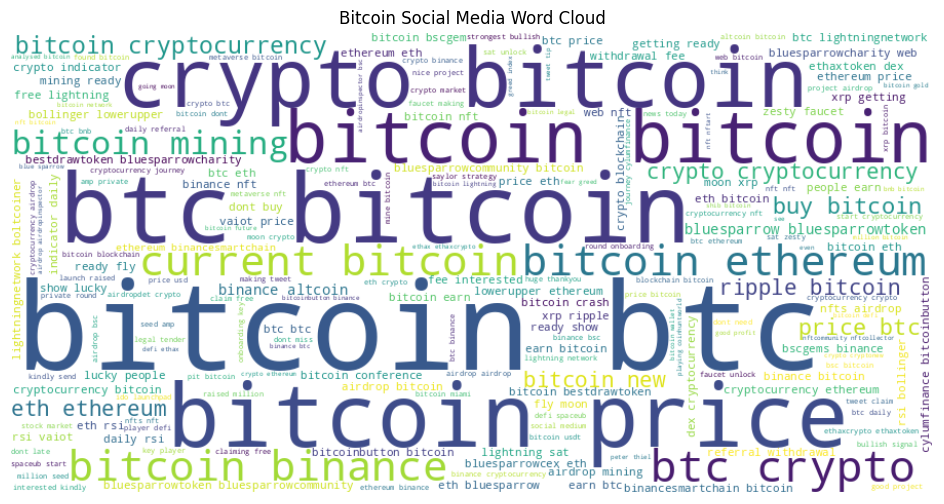

In [ ]:
wordcloud_text = " ".join(all_words)

wordcloud = WordCloud(
    width=900,
    height=450,
    background_color="white"
).generate(wordcloud_text)

plt.figure(figsize=(12, 6))
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")
plt.title("Bitcoin Social Media Word Cloud")
plt.show()

In [ ]:
def get_polarity(text):
    return TextBlob(str(text)).sentiment.polarity

def get_subjectivity(text):
    return TextBlob(str(text)).sentiment.subjectivity

df["sentiment_polarity"] = df["clean_text"].apply(get_polarity)
df["sentiment_subjectivity"] = df["clean_text"].apply(get_subjectivity)

def sentiment_label(score):
    if score > 0.05:
        return "Positive"
    elif score < -0.05:
        return "Negative"
    else:
        return "Neutral"

df["sentiment_label"] = df["sentiment_polarity"].apply(sentiment_label)

display(df[[text_col, "clean_text", "sentiment_polarity", "sentiment_subjectivity", "sentiment_label"]].head(10))

print("Sentiment counts:")
print(df["sentiment_label"].value_counts())

,text,clean_text,sentiment_polarity,sentiment_subjectivity,sentiment_label
0,I’m at @TheBitcoinConf in Miami checking out @...,miami checking trying snag bitcoin thisisarcul...,0.0,0.0,Neutral
1,I’m at @TheBitcoinConf in Miami checking out @...,miami checking trying snag bitcoin thisisarcul...,0.0,0.0,Neutral
2,I’m at @TheBitcoinConf in Miami checking out @...,miami checking trying snag bitcoin thisisarcul...,0.0,0.0,Neutral
3,I’m at @TheBitcoinConf in Miami checking out @...,miami checking trying snag bitcoin thisisarcul...,0.0,0.0,Neutral
4,I’m at @TheBitcoinConf in Miami checking out @...,miami checking trying snag bitcoin thisisarcul...,0.0,0.0,Neutral
5,I’m at @TheBitcoinConf in Miami checking out @...,miami checking trying snag bitcoin thisisarcul...,0.0,0.0,Neutral
6,I’m at @TheBitcoinConf in Miami checking out @...,miami checking trying snag bitcoin thisisarcul...,0.0,0.0,Neutral
7,I’m at @TheBitcoinConf in Miami checking out @...,miami checking trying snag bitcoin thisisarcul...,0.0,0.0,Neutral
8,I’m at @TheBitcoinConf in Miami checking out @...,miami checking trying snag bitcoin thisisarcul...,0.0,0.0,Neutral
9,I’m at @TheBitcoinConf in Miami checking out @...,miami checking trying snag bitcoin thisisarcul...,0.0,0.0,Neutral


Sentiment counts:
sentiment_label
Neutral     180879
Positive    162313
Negative     35499
Name: count, dtype: int64


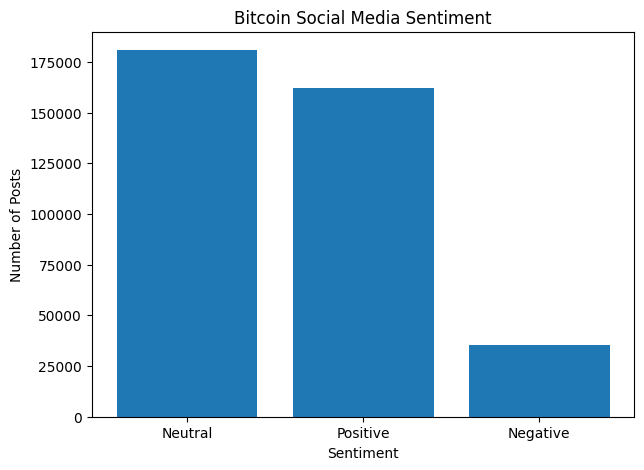

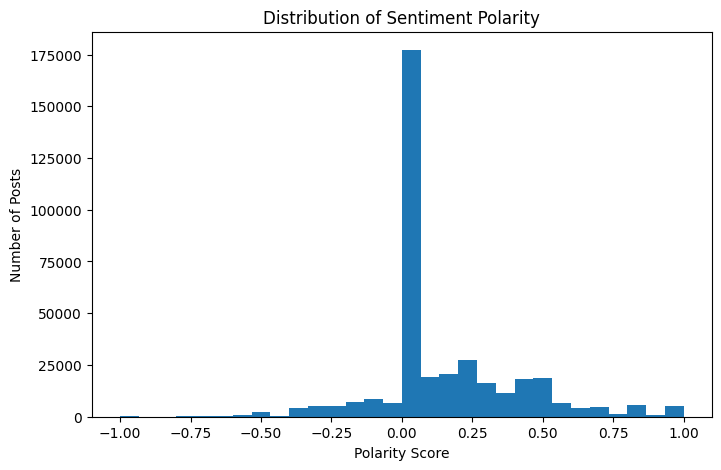

In [ ]:
sentiment_counts = df["sentiment_label"].value_counts()

plt.figure(figsize=(7, 5))
plt.bar(sentiment_counts.index, sentiment_counts.values)
plt.title("Bitcoin Social Media Sentiment")
plt.xlabel("Sentiment")
plt.ylabel("Number of Posts")
plt.show()

plt.figure(figsize=(8, 5))
plt.hist(df["sentiment_polarity"], bins=30)
plt.title("Distribution of Sentiment Polarity")
plt.xlabel("Polarity Score")
plt.ylabel("Number of Posts")
plt.show()

,source_file,total_posts,average_polarity,average_subjectivity
0,5-4 (1).xlsx,90336,0.128306,0.331130
1,6-4 (1).xlsx,92335,0.126232,0.324713
2,7-4 (1).xlsx,97709,0.132847,0.324977
3,8-4 (1).xlsx,98311,0.130470,0.324970


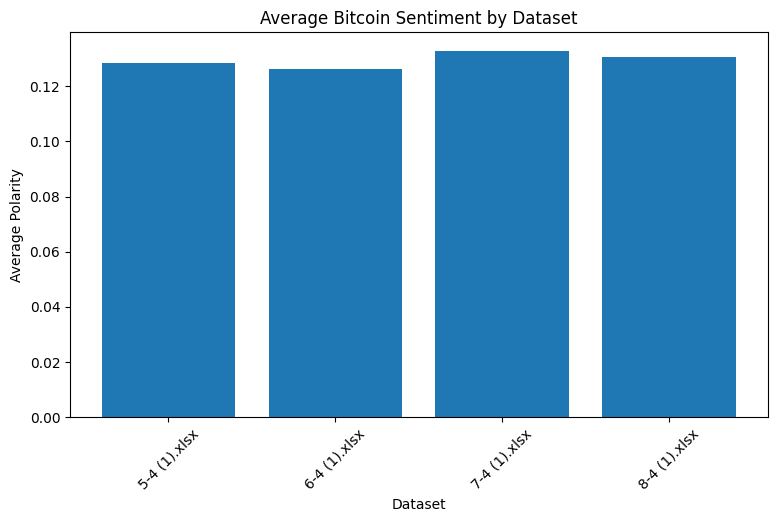

In [ ]:
sentiment_by_file = df.groupby("source_file").agg(
    total_posts=("clean_text", "count"),
    average_polarity=("sentiment_polarity", "mean"),
    average_subjectivity=("sentiment_subjectivity", "mean")
).reset_index()

display(sentiment_by_file)

plt.figure(figsize=(9, 5))
plt.bar(sentiment_by_file["source_file"], sentiment_by_file["average_polarity"])
plt.xticks(rotation=45)
plt.title("Average Bitcoin Sentiment by Dataset")
plt.xlabel("Dataset")
plt.ylabel("Average Polarity")
plt.show()

,hashtag,frequency
0,#bitcoin,234181
1,#btc,67496
2,#crypto,63097
3,#cryptocurrency,44535
4,#eth,40095
5,#ethereum,38879
6,#binance,35712
7,#nft,31855
8,#nfts,19277
9,#blockchain,17549


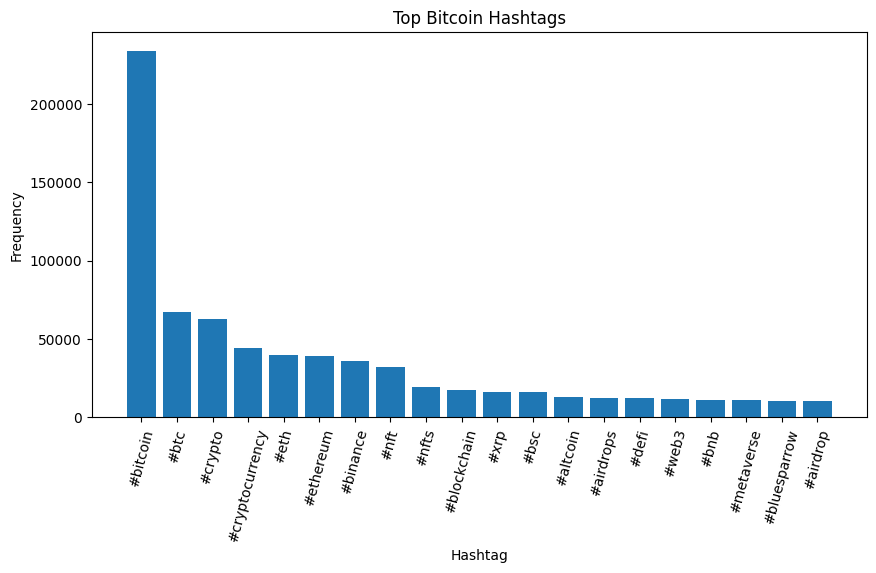

In [ ]:
def extract_hashtags(text):
    return re.findall(r"#\w+", str(text).lower())

df["hashtags"] = df[text_col].apply(extract_hashtags)

all_hashtags = []

for tags in df["hashtags"]:
    all_hashtags.extend(tags)

hashtag_freq = Counter(all_hashtags)

hashtag_df = pd.DataFrame(
    hashtag_freq.most_common(20),
    columns=["hashtag", "frequency"]
)

display(hashtag_df)

if len(hashtag_df) > 0:
    plt.figure(figsize=(10, 5))
    plt.bar(hashtag_df["hashtag"], hashtag_df["frequency"])
    plt.xticks(rotation=75)
    plt.title("Top Bitcoin Hashtags")
    plt.xlabel("Hashtag")
    plt.ylabel("Frequency")
    plt.show()
else:
    print("No hashtags found in the selected text column.")

,theme,matched_posts,average_polarity,positive_posts,neutral_posts,negative_posts
0,price_market,82785,0.082962,29506,46310,6969
1,investment,59154,0.128107,28823,23109,7222
2,crypto_general,365022,0.129424,156735,174121,34166
3,risk_security,11456,0.155186,6513,3994,949
4,promotion,90901,0.212228,50244,33224,7433


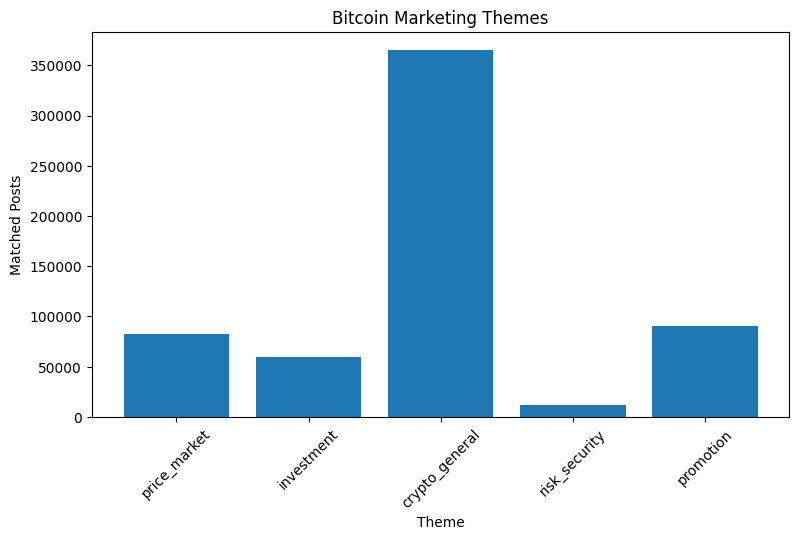

In [ ]:
# Testable marketing themes based on Bitcoin social media language

themes = {
    "price_market": ["price", "market", "bull", "bear", "trade", "trading"],
    "investment": ["buy", "sell", "hold", "invest", "investment", "profit"],
    "crypto_general": ["bitcoin", "btc", "crypto", "cryptocurrency", "ethereum", "blockchain"],
    "risk_security": ["risk", "scam", "fraud", "crash", "loss", "warning"],
    "promotion": ["airdrop", "giveaway", "project", "nft", "token", "launch"]
}

theme_results = []

for theme, keywords in themes.items():
    pattern = "|".join(keywords)

    subset = df[df["clean_text"].str.contains(pattern, case=False, na=False)]

    theme_results.append({
        "theme": theme,
        "matched_posts": len(subset),
        "average_polarity": subset["sentiment_polarity"].mean() if len(subset) > 0 else np.nan,
        "positive_posts": (subset["sentiment_label"] == "Positive").sum(),
        "neutral_posts": (subset["sentiment_label"] == "Neutral").sum(),
        "negative_posts": (subset["sentiment_label"] == "Negative").sum()
    })

theme_df = pd.DataFrame(theme_results)

display(theme_df)

plt.figure(figsize=(9, 5))
plt.bar(theme_df["theme"], theme_df["matched_posts"])
plt.xticks(rotation=45)
plt.title("Bitcoin Marketing Themes")
plt.xlabel("Theme")
plt.ylabel("Matched Posts")
plt.show()

In [ ]:
# Bot/spam risk check using repeated text and repeated promotional links

df["original_text_length"] = df[text_col].astype(str).str.len()
df["clean_text_length"] = df["clean_text"].astype(str).str.len()

repeated_posts = df["clean_text"].value_counts().reset_index()
repeated_posts.columns = ["clean_text", "repeat_count"]

display(repeated_posts.head(20))

df = df.merge(repeated_posts, on="clean_text", how="left")

df["possible_spam_or_bot"] = np.where(
    df["repeat_count"] >= 3,
    "Possible spam/repeated post",
    "Less repeated"
)

print("Spam/bot risk counts:")
print(df["possible_spam_or_bot"].value_counts())

display(df[[text_col, "clean_text", "repeat_count", "possible_spam_or_bot"]].head(10))

,clean_text,repeat_count
0,current bitcoin price btc crypto indicators da...,5637
1,xrp getting ready fly moon xrp ripple bitcoin ...,5557
2,dont buy bitcoin earn bitcoin mining ready sho...,2327
3,launch raised million seed amp private rounds ...,1837
4,bitcoin,1485
5,come dont late xrp bitcoin cryptocurrency binance,1259
6,know xrp moon crypto ripple bitcoin btc binanc...,1253
7,bitcoin gold gone bit xrp skyrocketed,1247
8,strongest bullish signal broken xrp bitcoin bt...,1243
9,world xrp religion ripple crypto cryptocurrenc...,1214


Spam/bot risk counts:
possible_spam_or_bot
Less repeated                  214887
Possible spam/repeated post    163804
Name: count, dtype: int64


,text,clean_text,repeat_count,possible_spam_or_bot
0,I’m at @TheBitcoinConf in Miami checking out @...,miami checking trying snag bitcoin thisisarcul...,737,Possible spam/repeated post
1,I’m at @TheBitcoinConf in Miami checking out @...,miami checking trying snag bitcoin thisisarcul...,737,Possible spam/repeated post
2,I’m at @TheBitcoinConf in Miami checking out @...,miami checking trying snag bitcoin thisisarcul...,737,Possible spam/repeated post
3,I’m at @TheBitcoinConf in Miami checking out @...,miami checking trying snag bitcoin thisisarcul...,737,Possible spam/repeated post
4,I’m at @TheBitcoinConf in Miami checking out @...,miami checking trying snag bitcoin thisisarcul...,737,Possible spam/repeated post
5,I’m at @TheBitcoinConf in Miami checking out @...,miami checking trying snag bitcoin thisisarcul...,737,Possible spam/repeated post
6,I’m at @TheBitcoinConf in Miami checking out @...,miami checking trying snag bitcoin thisisarcul...,737,Possible spam/repeated post
7,I’m at @TheBitcoinConf in Miami checking out @...,miami checking trying snag bitcoin thisisarcul...,737,Possible spam/repeated post
8,I’m at @TheBitcoinConf in Miami checking out @...,miami checking trying snag bitcoin thisisarcul...,737,Possible spam/repeated post
9,I’m at @TheBitcoinConf in Miami checking out @...,miami checking trying snag bitcoin thisisarcul...,737,Possible spam/repeated post


In [ ]:
clean_human_like_df = df[df["repeat_count"] < 3].copy()

print("Original average polarity:", round(df["sentiment_polarity"].mean(), 4))
print("After removing repeated posts:", round(clean_human_like_df["sentiment_polarity"].mean(), 4))

print("\nOriginal sentiment counts:")
print(df["sentiment_label"].value_counts())

print("\nAfter removing repeated posts:")
print(clean_human_like_df["sentiment_label"].value_counts())

Original average polarity: 0.1295
After removing repeated posts: 0.1248

Original sentiment counts:
sentiment_label
Neutral     180879
Positive    162313
Negative     35499
Name: count, dtype: int64

After removing repeated posts:
sentiment_label
Neutral     99786
Positive    93181
Negative    21920
Name: count, dtype: int64
